The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


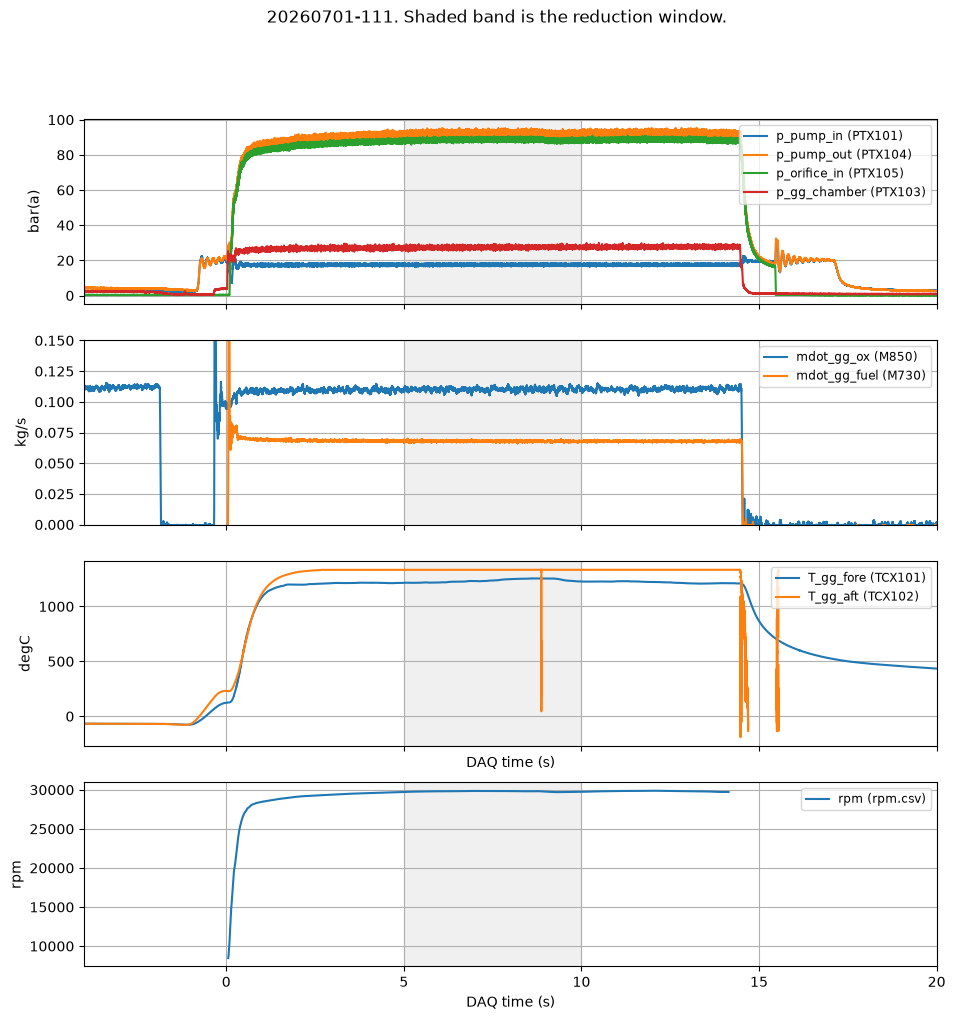

Average pump pressure rise: 74.275 bar, flow: 0.001 m^3/s, rpm: 29792.0 rpm pump inlet: 17.518 bar, pump outlet: 91.793 bar


In [17]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from otp.experiments.loaders.airborne import load_run


from data.OT2.ot2 import CHANNEL_MAP, DATA_PATH
run = load_run(DATA_PATH, cmap=CHANNEL_MAP)
STEADY_STATE_START, STEADY_STATE_END = (5.0, 10.0)
STEADY_STATE = (STEADY_STATE_START, STEADY_STATE_END)

import matplotlib.pyplot as plt
fig, axs = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

def smooth(x):
    return pd.Series(x).rolling(15, center=True).median().rolling(15, center=True).mean().to_numpy()

import pandas as pd
for n in ("p_pump_in", "p_pump_out", "p_orifice_in", "p_gg_chamber"):
    axs[0].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[0].set_ylabel("bar(a)")

for n in ("mdot_gg_ox", "mdot_gg_fuel"):
    axs[1].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[1].set_ylabel("kg/s")
axs[1].set_ylim(0, 0.15)

for n in ("T_gg_fore", "T_gg_aft"):
    axs[2].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[2].set_ylabel("degC"); axs[2].set_xlabel("DAQ time (s)")

for n in ("rpm",):
    axs[3].plot(run[n].t, run[n].v, label=f"{n} ({run[n].source})")
axs[3].set_ylabel("rpm"); axs[3].set_xlabel("DAQ time (s)")

for ax in axs:
    ax.grid(True); ax.legend(fontsize="small", loc="upper right")
    ax.axvspan(*STEADY_STATE, color="k", alpha=0.06)
axs[0].set_xlim(-4, 20)
fig.suptitle("20260701-111. Shaded band is the reduction window.");
plt.show()

# Find average values over the steady state window
# dp_average = run["dp_pump"].average(*STEADY_STATE)
avg_dp = run["dp_pump"].mean(STEADY_STATE_START, STEADY_STATE_END)
avg_Q = run["Q_pump"].mean(STEADY_STATE_START, STEADY_STATE_END)
avg_rpm = run["rpm"].mean(STEADY_STATE_START, STEADY_STATE_END)
avg_p_inlet = run["p_pump_in"].mean(STEADY_STATE_START, STEADY_STATE_END)
avg_p_outlet = run["p_pump_out"].mean(STEADY_STATE_START, STEADY_STATE_END)
print(f"Average pump pressure rise: {avg_dp:.3f} bar, flow: {avg_Q:.3f} m^3/s, rpm: {avg_rpm:.1f} rpm", f"pump inlet: {avg_p_inlet:.3f} bar, pump outlet: {avg_p_outlet:.3f} bar")


c:\Users\Martin\Active\otp-sizing\otp\pump\analysis.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  specific_speed = rpm * np.sqrt(Q) / (H_total_real)**0.75


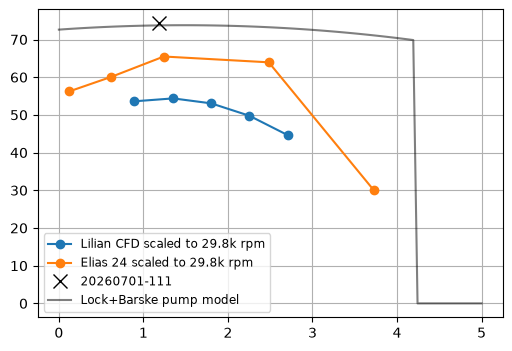

In [27]:
import pandas as pd

F = "barskE.xlsx"

runs = (pd.read_excel(F, usecols="I:AC", skiprows=25, nrows=13, index_col=0)
          .dropna(how="all")   # drops the blank spacer row
          .T)
runs.index.name = "run"
# columns: 'mdotin (kg/s)', 'mdotout (kg/s)', 'ptin (Pa)', 'dptot (Pa)', 'torque (Nm)',
#          'pHyd (W)', 'pShaft (W)', 'eta (-)', 'p_in (bar)', 'npspa (bar)', 'dp (bar)', 'pshaft (kW)'

cfd_33 = runs.loc[["run_01", "run_14", "run_15", "run_16", "run_17"]]
cfd_33 = cfd_33.rename(columns={
    "mdotin (kg/s)": "mdot (kg/s)",
    "pshaft (kW)":   "Pshaft (kW)",
    "eta (-)":       "eta",
})

elias_24 = pd.read_excel(F, usecols="B:E", skiprows=16, nrows=5)

def scale(df, N_new, N_old):
   r = N_new / N_old
   return df.assign(**{"mdot (kg/s)": df["mdot (kg/s)"] * r,
                        "dp (bar)":    df["dp (bar)"] * r**2,
                        "Pshaft (kW)": df["Pshaft (kW)"] * r**3})

fig, ax = plt.subplots(figsize=(6, 4))

cfd_30 = scale(cfd_33, N_new=avg_rpm, N_old=33_000)
elias_30 = scale(elias_24, N_new=avg_rpm, N_old=24_000)

ax.plot(cfd_30["mdot (kg/s)"], cfd_30["dp (bar)"], "-o", label="Lilian CFD scaled to 29.8k rpm")
ax.plot(elias_30["mdot (kg/s)"], elias_30["dp (bar)"], "-o", label="Elias 24 scaled to 29.8k rpm")
ax.plot(avg_Q*1e3, avg_dp, "x", label="20260701-111", markersize=10, color="k")

from data.OT2.ot2 import PUMP
from pyfluids import FluidsList
from otp.propellants.propellant import Propellant
from otp.core.units import BAR
import numpy as np


WATER = Propellant("Water", FluidsList.Water, t_tank=293.15, p_tank=10*BAR)

dps = np.array([PUMP.point_performance(WATER, Q, avg_rpm, avg_p_inlet*BAR, 293.15, "lock").dp for Q in np.linspace(0, 0.005, 100)])
ax.plot(np.linspace(0, 0.005, 100)*1e3, dps/BAR, label="Lock+Barske pump model", color="k", alpha=0.5)

ax.legend(fontsize="small")
ax.grid(True)